# Statistical Arbitrage: Pairs Trading

This project develops and evaluates a statistical-arbitrage pairs trading
strategy using Coca-Cola (KO) and PepsiCo (PEP).

The project investigates whether the two stocks exhibit a stable long-run
relationship and whether deviations from this relationship can be exploited
through a mean-reversion strategy.

**Contents**:
1. Introduction
2. Data Correlation and Cointegration


# 1. Introduction

Statistical arbitrage is a quantitative trading approach that attempts to identify statistical relationships between financial assets and exploit temporary deviations from these relationships.

In this project, a pairs-trading strategy is investigated. The strategy involves identifying two assets with a stable long-run relationship, constructing a spread between them, and taking positions when the spread deviates significantly from its historical behaviour.

The strategy is then backtested using historical market data and evaluated using risk-adjusted performance measures. Transaction costs and slippage are also considered to assess whether the strategy remains viable under more realistic trading conditions.

# 2. Data Correlation and Cointegration

Historical daily price data for Coca-Cola (KO) and PepsiCo (PEP) is used from 2015 to 2024. They were selected because they operate in the same industry and are exposed to similar economic factors.

The first step is to examine whether the two stocks tend to move together. Correlation measures the degree to which their short-term price movements are related. However, high correlation alone does not imply that the relationship between their prices is stable over the long term. Therefore, correlation is used as an initial diagnostic rather than as evidence that a pairs-trading strategy should work. Cointegration describes a stable long-run relationship between two non-stationary price series. Although KO and PEP prices may each trend over time, a particular linear combination of their prices may be stationary. This means that deviations from their long-run relationship tend to be temporary rather than growing without bound. The Engle-Granger cointegration test is used to determine whether such a relationship exists.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

## 2.1 Historical Market Data


In [2]:
tickers = ["KO", "PEP"]

data = yf.download(
    tickers,
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=True
)

#downloading data

[*********************100%***********************]  2 of 2 completed


In [3]:
data.head()

#outputting first few rows of data

Price           Close                  High                   Low             \
Ticker             KO        PEP         KO        PEP         KO        PEP   
Date                                                                           
2015-01-02  29.390270  66.582909  29.571607  67.217430  29.153139  66.307948   
2015-01-05  29.390270  66.082367  29.969150  67.013005  29.348425  66.075315   
2015-01-06  29.613447  65.581779  29.948220  66.709830  29.460011  65.525381   
2015-01-07  29.983089  67.499481  30.066782  67.844949  29.697138  66.575895   
2015-01-08  30.345755  68.726242  30.387602  69.029405  30.059803  68.162217   

Price            Open               Volume           
Ticker             KO        PEP        KO      PEP  
Date                                                 
2015-01-02  29.473963  66.928371   9921100  3545700  
2015-01-05  29.773864  66.589983  26292600  6441000  
2015-01-06  29.578576  66.329114  16897500  6195000  
2015-01-07  29.850574  67.069413  13412300  6526300  
2015-01-08  30.115600  68.204517  21743600  7131600

In [4]:
prices = data["Close"].copy()

prices.head()

#outputting the 'close' datas from all data

Ticker,KO,PEP
Date,,
2015-01-02,29.390270,66.582909
2015-01-05,29.390270,66.082367
2015-01-06,29.613447,65.581779
2015-01-07,29.983089,67.499481
2015-01-08,30.345755,68.726242


In [5]:
prices.shape

#outputs the number of rows and columns of data needed

(2516, 2)

### 2.1.1 Data Quality Checks

In [6]:
prices.info()

#checking whether data entries are reasonable

<class 'pandas.DataFrame'>
DatetimeIndex: 2516 entries, 2015-01-02 to 2024-12-31
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   KO      2516 non-null   float64
 1   PEP     2516 non-null   float64
dtypes: float64(2)
memory usage: 59.0 KB


In [7]:
prices.isna().sum()

#counts how many data entries are 'NA'

Ticker
KO     0
PEP    0
dtype: int64

In [8]:
prices = prices.dropna()
prices.isna().sum()

#deletes all rows with entries as 'NA' and counting again

Ticker
KO     0
PEP    0
dtype: int64

## 2.2 Price History

The historical prices of the two assets are plotted to provide an initial
visual assessment of their behaviour and common trends.

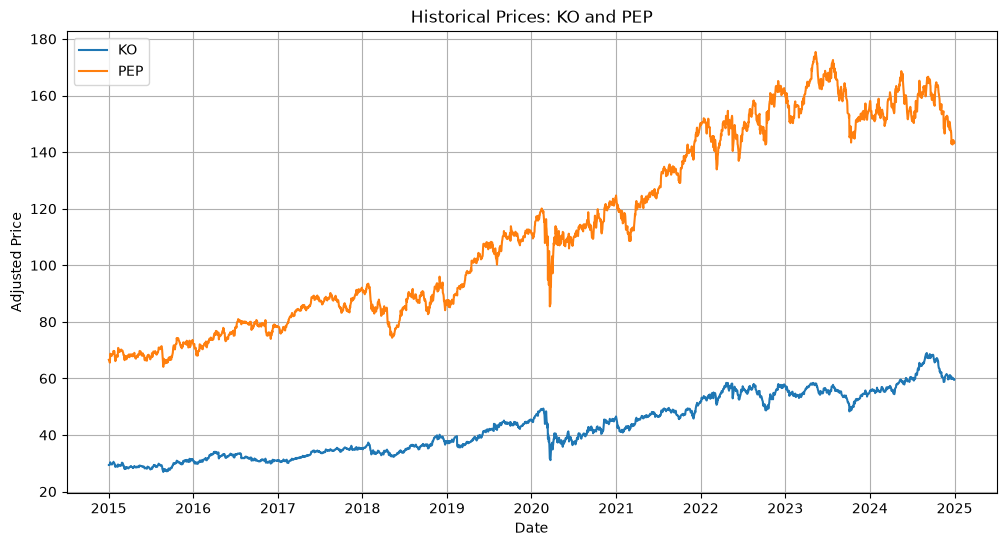

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(prices["KO"], label="KO")
plt.plot(prices["PEP"], label="PEP")

plt.title("Historical Prices: KO and PEP")
plt.xlabel("Date")
plt.ylabel("Adjusted Price")
plt.legend()
plt.grid(True)

plt.show()

#plotting a graph of the prices of KO and PEP; they look like they have similar ups and downs

In [10]:
returns = prices.pct_change().dropna()
returns.head()

#outputs a list of percentage changes i.e. returns

Ticker,KO,PEP
Date,,
2015-01-05,0.000000,-0.007518
2015-01-06,0.007594,-0.007575
2015-01-07,0.012482,0.029241
2015-01-08,0.012096,0.018174
2015-01-09,-0.011032,-0.006771


In [11]:
correlation = returns["KO"].corr(returns["PEP"])

print(f"Daily return correlation: {correlation:.4f}")

#the correlation between returns is calculated; they seem to be quite correlated

Daily return correlation: 0.7400


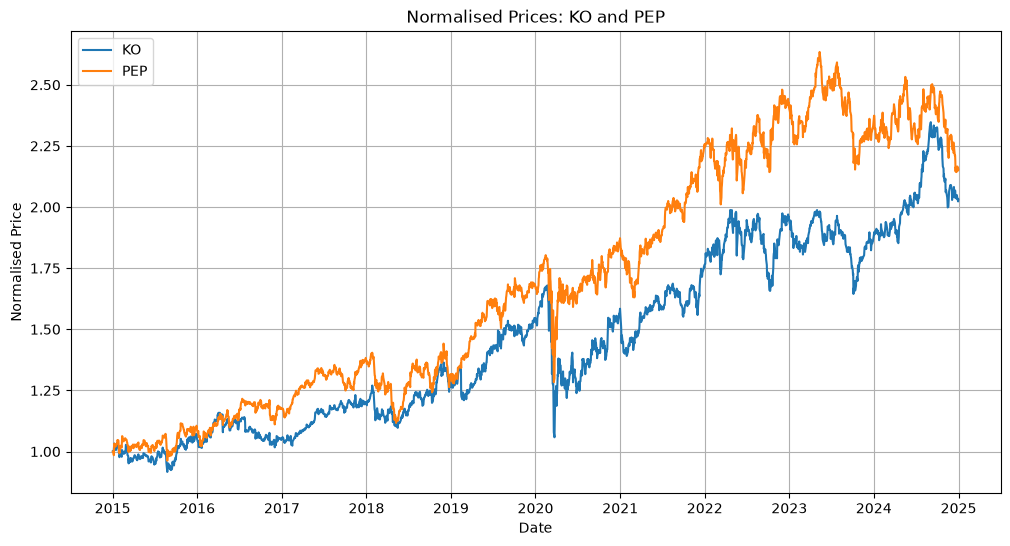

In [12]:
normalised_prices = prices / prices.iloc[0]

plt.figure(figsize=(12, 6))

plt.plot(normalised_prices["KO"], label="KO")
plt.plot(normalised_prices["PEP"], label="PEP")

plt.title("Normalised Prices: KO and PEP")
plt.xlabel("Date")
plt.ylabel("Normalised Price")
plt.legend()
plt.grid(True)

plt.show()

#prices are scaled so both KO and PEP start at 1.00; graph of prices plotted again

## 2.3 Linear Regression

We model the price of KO as a linear function of the price of PEP:

$$
P_{KO,t} = \alpha + \beta P_{PEP,t} + \epsilon_t
$$

The estimated coefficient $\beta$ will be used as the hedge ratio when
constructing the spread between the two assets. The hedge ratio determines how much of one stock should be held relative to the other in order to isolate their relative pricing relationship.

In [13]:
x = sm.add_constant(prices["PEP"])
y = prices["KO"]

model = sm.OLS(y, x).fit()

print(model.summary())

#ordinary least square (OLS) regression used to determine hedge ratio

                            OLS Regression Results                            
Dep. Variable:                     KO   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                 4.207e+04
Date:                Fri, 04 Sep 2026   Prob (F-statistic):               0.00
Time:                        00:44:28   Log-Likelihood:                -5888.1
No. Observations:                2516   AIC:                         1.178e+04
Df Residuals:                    2514   BIC:                         1.179e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.8237      0.178     43.913      0.0

In [14]:
alpha = model.params["const"]
beta = model.params["PEP"]

print(f"Alpha: {alpha:.4f}")
print(f"Beta: {beta:.4f}")

#alpha and beta printed out

Alpha: 7.8237
Beta: 0.3110


## 2.4 Spread Construction

Using the estimated hedge ratio $\beta$, we define the spread as:

$$
S_t=P_{KO,t}-\beta P_{PEP,t}.
$$

The spread represents the deviation of KO's price from the level implied by
its estimated relationship with PEP.

For a pairs-trading strategy, we are interested in whether this spread
exhibits mean-reverting behaviour.

In [15]:
spread = prices["KO"] - beta * prices["PEP"]

spread.head()

#printing out the first few rows of the spread

Date
2015-01-02    8.682548
2015-01-05    8.838220
2015-01-06    9.217083
2015-01-07    8.990307
2015-01-08    8.971441
dtype: float64

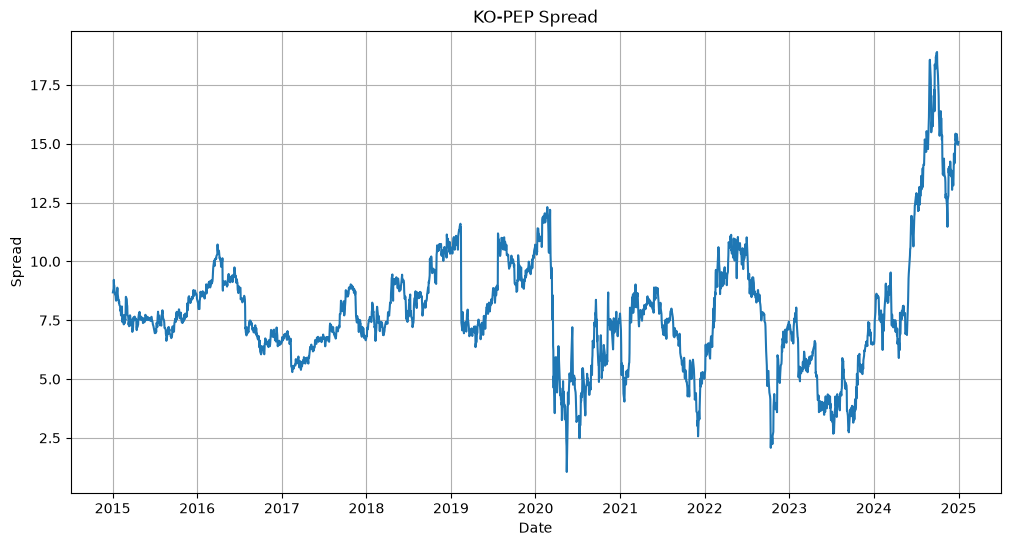

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(spread)

plt.title("KO-PEP Spread")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.grid(True)

plt.show()

#graph of spread plotted

## 2.5 Cointegration Test

We use the Engle-Granger cointegration test to determine whether KO and PEP
share a statistically significant long-run relationship.

The null hypothesis is that the two series are not cointegrated.

A sufficiently small p-value provides evidence against the null hypothesis.

In [17]:
coint_stat, p_value, critical_values = coint(
    prices["KO"],
    prices["PEP"]
)

print(f"Cointegration test statistic: {coint_stat:.4f}")
print(f"p-value: {p_value:.4f}")

print("\nCritical values:")
print(f"1%:  {critical_values[0]:.4f}")
print(f"5%:  {critical_values[1]:.4f}")
print(f"10%: {critical_values[2]:.4f}")

#cointegration test; we compare the test statistic and the critical values at different significance levels

Cointegration test statistic: -2.4560
p-value: 0.2988

Critical values:
1%:  -3.9008
5%:  -3.3386
10%: -3.0461


### Interpretation

The estimated regression produced a hedge ratio of approximately

$$
\beta = 0.3110.
$$

However, the Engle-Granger cointegration test produced a p-value of

$$
p = 0.2988.
$$

Using a 5% significance level, we fail to reject the null hypothesis i.e. the two price series are not cointegrated.

Therefore, there is insufficient statistical evidence to conclude that KO
and PEP share a stable long-run relationship over the sample period.

# 3. Training and Test Data

To avoid look-ahead bias, the data is divided into a training period from 2015–2021 and an out-of-sample test period from 2022–2024.

The training period is used to investigate relationships between assets,
estimate model parameters, and develop the trading strategy.

The test period is kept separate and is used only for evaluating the
performance of the final strategy.

The periods are defined as:

- Training: 2015-01-01 to 2021-12-31
- Testing: 2022-01-01 to 2024-12-31

In [18]:
train = prices.loc["2015-01-01":"2021-12-31"].copy()

train.head()

#separating the training and testing data; outputting the start, end, and shape of both sets

Ticker,KO,PEP
Date,,
2015-01-02,29.390270,66.582909
2015-01-05,29.390270,66.082367
2015-01-06,29.613447,65.581779
2015-01-07,29.983089,67.499481
2015-01-08,30.345755,68.726242


In [19]:
train.tail()

Ticker,KO,PEP
Date,,
2021-12-27,51.363140,148.359299
2021-12-28,51.564560,149.129333
2021-12-29,51.625866,149.657089
2021-12-30,51.476982,149.397537
2021-12-31,51.853558,150.297409


In [20]:
train.shape

(1763, 2)

In [21]:
test = prices.loc["2022-01-01":"2024-12-31"].copy()

test.head()

Ticker,KO,PEP
Date,,
2022-01-03,51.932377,149.665756
2022-01-04,52.799377,149.882080
2022-01-05,53.237263,150.392548
2022-01-06,52.957012,150.427170
2022-01-07,52.834408,150.617538


In [22]:
test.tail()

Ticker,KO,PEP
Date,,
2024-12-24,60.233421,144.120697
2024-12-26,59.974621,143.771744
2024-12-27,59.859600,144.196136
2024-12-30,59.457020,143.092682
2024-12-31,59.677479,143.413345


In [23]:
test.shape

(753, 2)

## 3.1 Training and Test Periods

The training and test periods are plotted below to verify the chronological
split of the dataset.

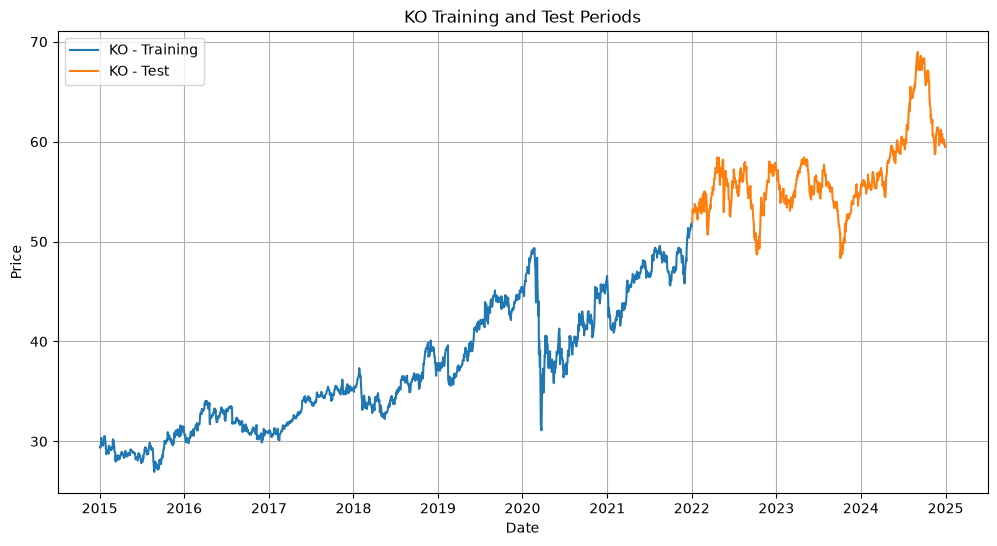

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(train["KO"], label="KO - Training")
plt.plot(test["KO"], label="KO - Test")

plt.title("KO Training and Test Periods")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

#graph of both sets of data plotted together with different colours

## 3.2 Estimating the Hedge Ratio

The hedge ratio is estimated using only the training period.

We model the price of KO as:

$$
P_{KO,t} = \alpha_{\text{train}} + \beta_{\text{train}} P_{PEP,t} + \epsilon_t.
$$

The estimated coefficient $\beta$ is then used to construct the spread.

In [25]:
X_train = sm.add_constant(train["PEP"])
y_train = train["KO"]

train_model = sm.OLS(y_train, X_train).fit()

print(train_model.summary())

#similar to above, OLS regression used on the training set only to acquire alpha and beta

                            OLS Regression Results                            
Dep. Variable:                     KO   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.925
Method:                 Least Squares   F-statistic:                 2.181e+04
Date:                Fri, 04 Sep 2026   Prob (F-statistic):               0.00
Time:                        00:44:30   Log-Likelihood:                -3434.8
No. Observations:                1763   AIC:                             6874.
Df Residuals:                    1761   BIC:                             6885.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.4377      0.191     49.358      0.0

In [26]:
alpha_train = train_model.params["const"]
beta_train = train_model.params["PEP"]

print(f"Training alpha: {alpha_train:.4f}")
print(f"Training beta: {beta_train:.4f}")

#training alpha and beta printed

Training alpha: 9.4377
Training beta: 0.2921


In [27]:
train_coint_stat, train_p_value, train_critical_values = coint(
    train["KO"],
    train["PEP"]
)

print(f"Training cointegration statistic: {train_coint_stat:.4f}")
print(f"Training p-value: {train_p_value:.4f}")

print("\nCritical values:")
print(f"1%:  {train_critical_values[0]:.4f}")
print(f"5%:  {train_critical_values[1]:.4f}")
print(f"10%: {train_critical_values[2]:.4f}")

#cointegration test: now we can conclude that at a 5% sig. level, KO and PEP are cointegrated

Training cointegration statistic: -3.6015
Training p-value: 0.0244

Critical values:
1%:  -3.9027
5%:  -3.3396
10%: -3.0469


## 3.3 Constructing the Training Spread

The hedge ratio estimated from the training period is used to construct the
spread:

$$
S_t=P_{KO,t}-\beta P_{PEP,t}.
$$

Using the estimated training-period hedge ratio, $\beta = 0.2921$, the spread is:

$$
S_t=P_{KO,t}-0.2921P_{PEP,t}.
$$

Rather than betting on whether the overall stock market will rise or fall, the strategy trades this relative spread. The spread will be used to investigate whether deviations from the long-run relationship tend to reverse over time.

In [28]:
spread_train = train["KO"] - beta_train * train["PEP"]

spread_train.head()

#acquire training spread using training beta

Date
2015-01-02     9.939272
2015-01-05    10.085496
2015-01-06    10.454911
2015-01-07    10.264331
2015-01-08    10.268620
dtype: float64

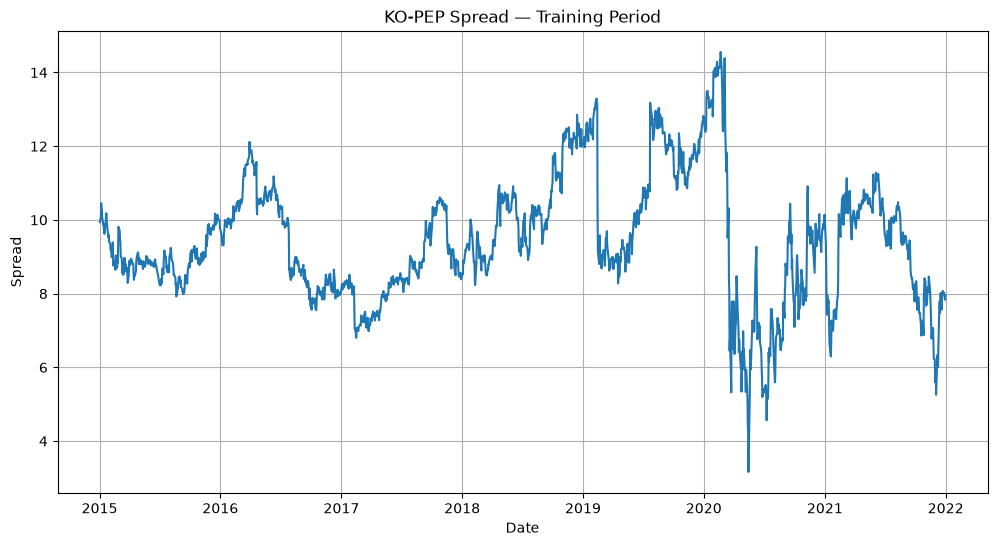

In [29]:
plt.figure(figsize=(12, 6))

plt.plot(spread_train)

plt.title("KO-PEP Spread — Training Period")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.grid(True)

plt.show()

#graph of training spread plotted

In [30]:
spread_mean = spread_train.mean()
spread_std = spread_train.std()

print(f"Spread mean: {spread_mean:.4f}")
print(f"Spread standard deviation: {spread_std:.4f}")

#mean and standard deviation of training spread calculated

Spread mean: 9.4377
Spread standard deviation: 1.6983


## 3.4 Spread Z-Score

To measure how far the current spread is from its historical mean, we
standardise the spread using its z-score:

$$
Z_t=\frac{S_t-\mu_S}{\sigma_S}.
$$

A z-score of 0 indicates that the spread is at its historical mean. A large positive z-score indicates that KO is relatively expensive compared with PEP, while a large negative z-score indicates the opposite.

In [31]:
zscore_train = (spread_train - spread_mean) / spread_std

zscore_train.head()

#training z-scores calculated and the first few are shown

Date
2015-01-02    0.295351
2015-01-05    0.381451
2015-01-06    0.598969
2015-01-07    0.486752
2015-01-08    0.489278
dtype: float64

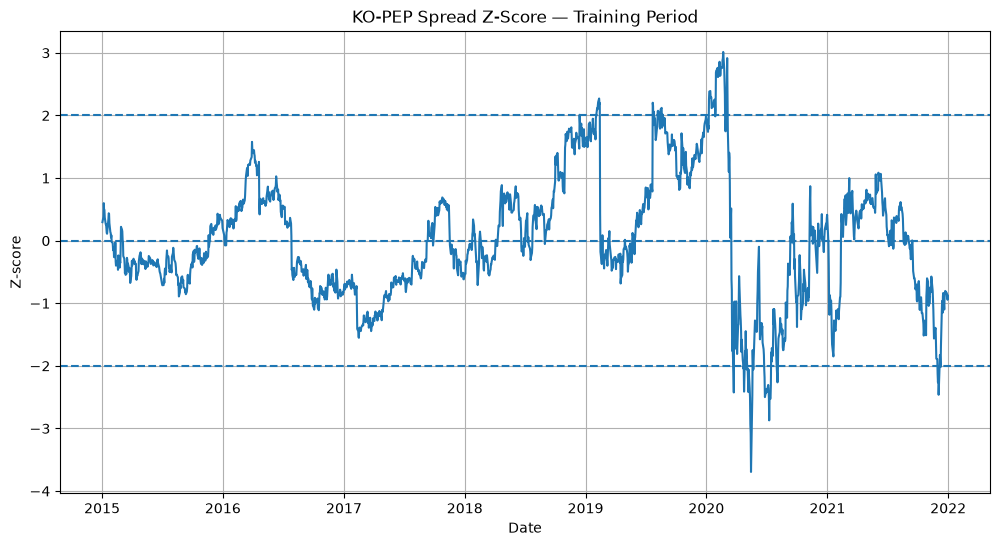

In [32]:
plt.figure(figsize=(12, 6))

plt.plot(zscore_train)

plt.axhline(0, linestyle="--")
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")

plt.title("KO-PEP Spread Z-Score — Training Period")
plt.xlabel("Date")
plt.ylabel("Z-score")

plt.grid(True)

plt.show()

#graph of training z-score plotted

## 3.5 Trading Strategy and Backtesting

The strategy exploits deviations of the spread from its historical mean.

A long position in the spread is established when the z-score falls below
-2, indicating that the spread is unusually low.

A short position in the spread is established when the z-score rises above
+2, indicating that the spread is unusually high.

Positions are closed when the z-score returns to 0.

In [33]:
def run_pairs_strategy(zscore, entry_threshold, exit_threshold):
    position = pd.Series(index=zscore.index,dtype=float)
    current_position = 0

    for date in zscore.index:
        z = zscore.loc[date]
        if current_position == 0:
            if z < -entry_threshold:
                current_position = 1
            elif z > entry_threshold:
                current_position = -1
        elif current_position == 1:
            if z >= exit_threshold:
                current_position = 0
        elif current_position == -1:
            if z <= -exit_threshold:
                current_position = 0

        position.loc[date] = current_position
    return position

#the trading strategy utilised in this project; when the z-score deviates too much from 0, we expect it to revert

In [34]:
position = run_pairs_strategy(zscore_train,2,0)

#in this case when |z-score|>2 then we enter long/short trade according to its parity, and we exit the trade when z-score reaches and 'exceeds' 0

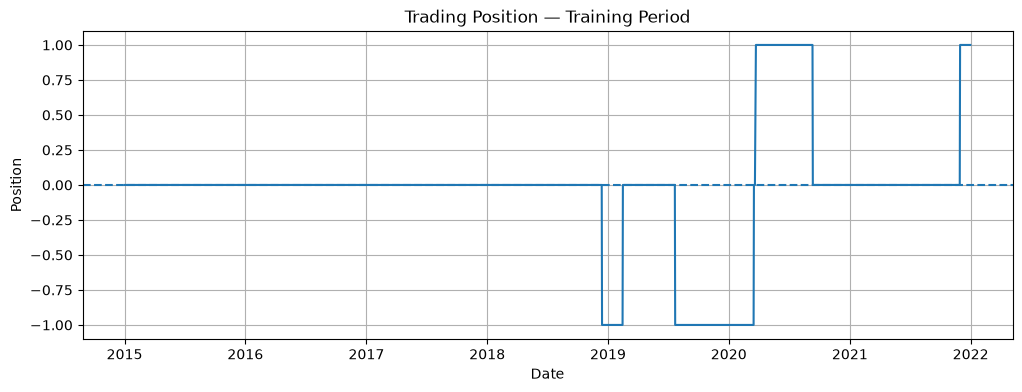

In [35]:
plt.figure(figsize=(12, 4))

plt.plot(position)

plt.axhline(0, linestyle="--")

plt.title("Trading Position — Training Period")
plt.xlabel("Date")
plt.ylabel("Position")

plt.grid(True)

plt.show()

#graph of trading positions: start/end dates, lengths and nature of each trade can be observed

In [36]:
position.value_counts()

#count of how many days of no trade, high trade, low trade

 0.0    1414
-1.0     206
 1.0     143
Name: count, dtype: int64

In [37]:
trades = position.diff().abs()

number_of_trades = (trades > 0).sum()

print(f"Number of position changes: {number_of_trades}")

#number of entry/exit i.e. position changes; it is odd here because the final trade has not exitted

Number of position changes: 7


In [38]:
train_returns = train.pct_change()
train_returns.head()

#the first few rows of percentage changes in training period is shown

Ticker,KO,PEP
Date,,
2015-01-02,NaN,NaN
2015-01-05,0.000000,-0.007518
2015-01-06,0.007594,-0.007575
2015-01-07,0.012482,0.029241
2015-01-08,0.012096,0.018174


### 3.5.1 Portfolio Profit and Loss (P&L)

The trading position consists of one share of KO and a hedge position of
$\beta$ shares of PEP.

The daily dollar P&L of one spread unit is therefore:

$$
\Delta P^{spread}_t
=
\Delta P_{KO,t}
-
\beta\Delta P_{PEP,t}.
$$

To express this as a portfolio return, the P&L is divided by the gross
notional of the two positions:

$$
R^{spread}_t
=
\frac{
\Delta P_{KO,t}-\beta\Delta P_{PEP,t}
}{
P_{KO,t-1}+\beta P_{PEP,t-1}
}.
$$

The trading position from the previous day is then applied to this return
to avoid look-ahead bias.

In [39]:
ko_change = train["KO"].diff()
pep_change = train["PEP"].diff()

spread_pnl = ko_change - beta_train * pep_change
spread_pnl.head()

#spread p&l calculated and first few rows shown

Date
2015-01-02         NaN
2015-01-05    0.146224
2015-01-06    0.369415
2015-01-07   -0.190580
2015-01-08    0.004289
dtype: float64

In [40]:
gross_notional = (
    train["KO"].shift(1)
    + beta_train * train["PEP"].shift(1)
)

spread_portfolio_return = spread_pnl / gross_notional
spread_portfolio_return.head()

# portfolio return calculated and first few rows shown

Date
2015-01-02         NaN
2015-01-05    0.002994
2015-01-06    0.007586
2015-01-07   -0.003908
2015-01-08    0.000086
dtype: float64

### 3.5.2 Strategy Returns

The spread consists of a long position in KO and a short position in PEP
scaled by the hedge ratio $\beta$.

The daily spread return is therefore approximated by:

$$
R^{spread}_t
=
R^{KO}_t-\beta R^{PEP}_t.
$$

To avoid look-ahead bias, the position determined using information at time
$t-1$ is applied to the return observed at time $t$.

In [41]:
strategy_returns = (
    position.shift(1) * spread_portfolio_return
).dropna()
strategy_returns.describe()

# a few statistics for the strategy returns calculated

count    1762.000000
mean        0.000115
std         0.002938
min        -0.019668
25%         0.000000
50%        -0.000000
75%        -0.000000
max         0.045217
dtype: float64

In [42]:
strategy_returns[strategy_returns != 0].head(10)
#the first few rows of percentage changes in training period that is not 0 is shown

Date
2018-12-17    0.008427
2018-12-18   -0.003571
2018-12-19   -0.001289
2018-12-20    0.005122
2018-12-21   -0.003266
2018-12-24    0.007838
2018-12-26   -0.004036
2018-12-27   -0.003472
2018-12-28    0.007604
2018-12-31   -0.001450
dtype: float64

In [43]:
strategy_returns.abs().sum()

#total strategy returns calculated

np.float64(1.4876111717244016)

### 3.5.3 Cumulative Strategy Performance

The cumulative value of the strategy is calculated by compounding the daily
strategy returns:

$$
C_t=\prod_{i=1}^{t}(1+R_i).
$$

This allows us to visualise how the strategy's value changes over the
training period.

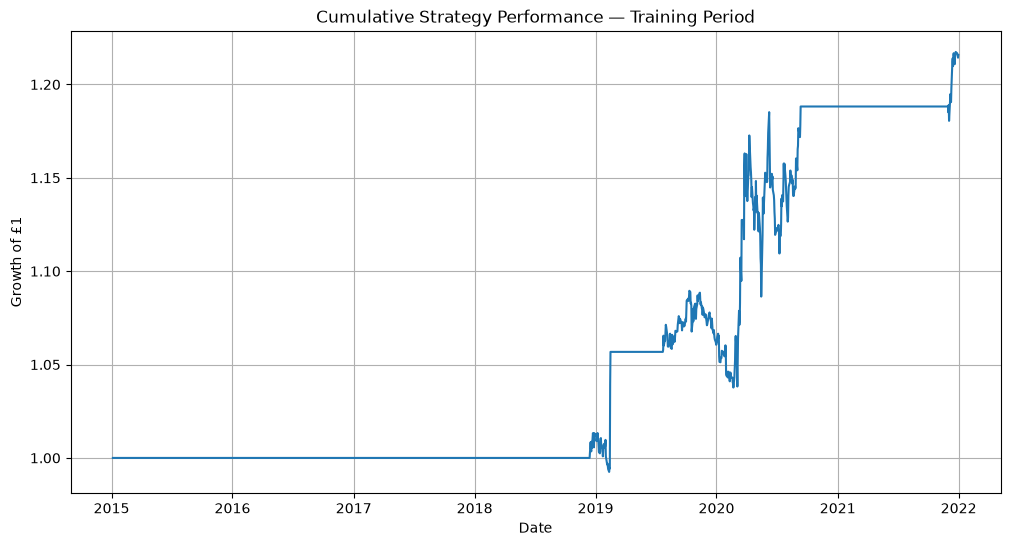

In [44]:
cumulative_strategy = (1 + strategy_returns).cumprod()
plt.figure(figsize=(12, 6))

plt.plot(cumulative_strategy)

plt.title("Cumulative Strategy Performance — Training Period")
plt.xlabel("Date")
plt.ylabel("Growth of £1")

plt.grid(True)

plt.show()
#cumulative strategy calculated and plotted

In [45]:
total_return = cumulative_strategy.iloc[-1] - 1

print(f"Total strategy return: {total_return:.2%}")
#total strategy return calculated

Total strategy return: 21.58%


### 3.5.4 Sharpe Ratio

The Sharpe ratio measures the return generated by the strategy relative to
the volatility of those returns.

Assuming approximately 252 trading days per year, the annualised Sharpe ratio
is calculated as:

$$
Sharpe =
\frac{\mu_R}{\sigma_R}\sqrt{252},
$$

where $\mu_R$ is the mean daily strategy return and $\sigma_R$ is the
standard deviation of daily strategy returns.

A higher Sharpe ratio indicates better risk-adjusted performance.

In [46]:
mean_daily_return = strategy_returns.mean()
daily_volatility = strategy_returns.std()

sharpe_ratio = (
    mean_daily_return / daily_volatility
) * np.sqrt(252)

print(f"Mean daily return: {mean_daily_return:.6f}")
print(f"Daily volatility: {daily_volatility:.6f}")
print(f"Annualised Sharpe ratio: {sharpe_ratio:.4f}")

#calculations with results printed

Mean daily return: 0.000115
Daily volatility: 0.002938
Annualised Sharpe ratio: 0.6223


### 3.5.5 Maximum Drawdown

Maximum drawdown measures the largest percentage decline in the strategy's
cumulative value from a previous peak.

For a cumulative value $C_t$, the running maximum is:

$$
M_t = \max_{s \leq t} C_s.
$$

The drawdown is then:

$$
D_t = \frac{C_t-M_t}{M_t}.
$$

The maximum drawdown is the minimum value of $D_t$.

In [47]:
running_max = cumulative_strategy.cummax()

drawdown = (
    cumulative_strategy - running_max
) / running_max

max_drawdown = drawdown.min()

print(f"Maximum drawdown: {max_drawdown:.2%}")

#max drawdown calculated

Maximum drawdown: -7.36%


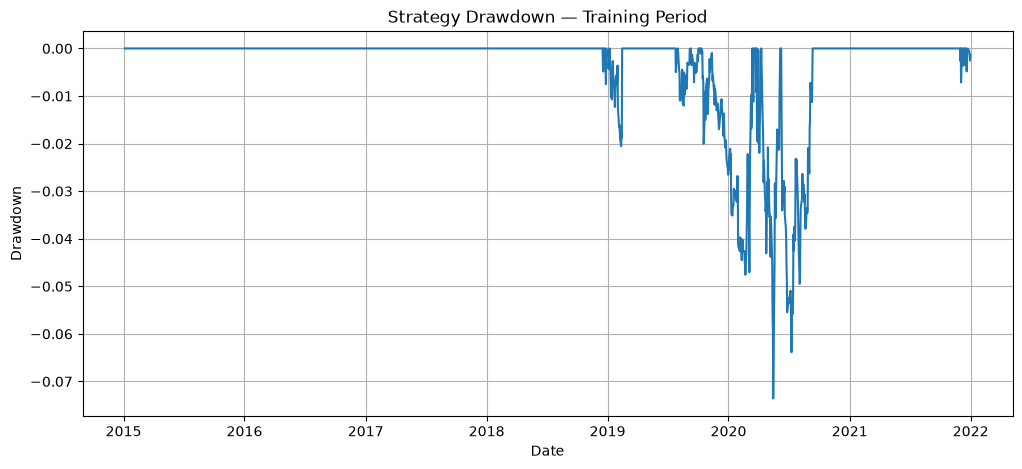

In [48]:
plt.figure(figsize=(12, 5))

plt.plot(drawdown)

plt.title("Strategy Drawdown — Training Period")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.grid(True)

plt.show()

#graph of drawdown in training period plotted

### 3.5.6 Transaction Costs

The backtest is extended to account for transaction costs, which is assumed as 0.10% for traded notional.

Transaction costs are incurred whenever the trading position changes.

The cost is proportional to the absolute change in the position:

$$
Cost_t = c|\Delta Position_t|,
$$

where $c$ is the assumed transaction cost.

In [49]:
transaction_cost = 0.001
position_change = position.diff().abs()
costs = transaction_cost * position_change
costs = costs.fillna(0)

costs[costs>0]

#dates with nonzero cost i.e. entry/exit dates along with the cost is printed

Date
2018-12-14    0.001
2019-02-15    0.001
2019-07-23    0.001
2020-03-17    0.001
2020-03-23    0.001
2020-09-11    0.001
2021-11-30    0.001
dtype: float64

In [50]:
strategy_returns_net = strategy_returns - costs.loc[strategy_returns.index]
cumulative_strategy_net = (1 + strategy_returns_net).cumprod()

In [51]:
gross_total_return = cumulative_strategy.iloc[-1] - 1
net_total_return = cumulative_strategy_net.iloc[-1] - 1

print(f"Gross total return: {gross_total_return:.2%}")
print(f"Net total return:   {net_total_return:.2%}")

net_sharpe = strategy_returns_net.mean()/strategy_returns_net.std()*np.sqrt(252)

print(f"Gross Sharpe ratio: {sharpe_ratio:.4f}")
print(f"Net Sharpe ratio:   {net_sharpe:.4f}")

#calculations

Gross total return: 21.58%
Net total return:   20.74%
Gross Sharpe ratio: 0.6223
Net Sharpe ratio:   0.6029


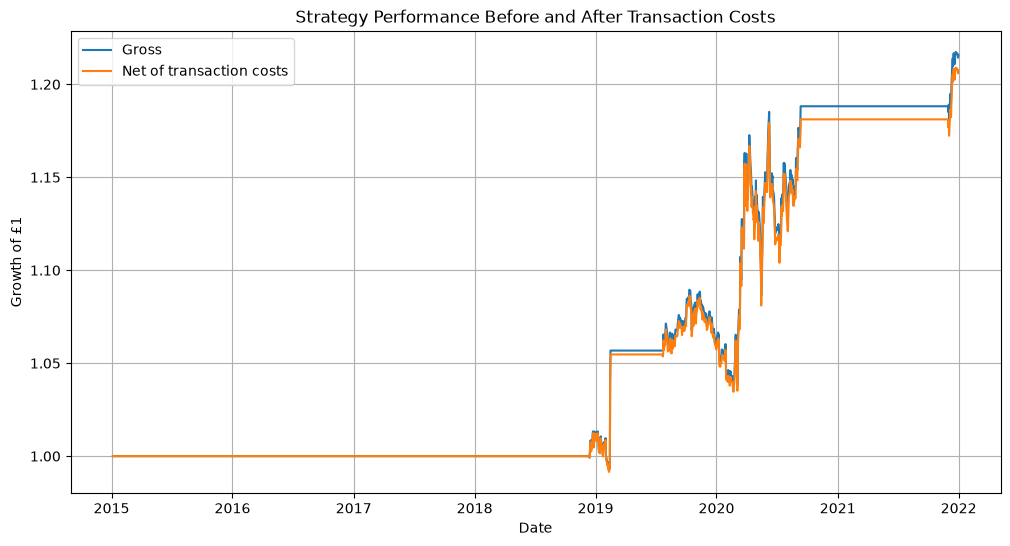

In [52]:
plt.figure(figsize=(12, 6))

plt.plot(cumulative_strategy, label="Gross")
plt.plot(cumulative_strategy_net, label="Net of transaction costs")

plt.title("Strategy Performance Before and After Transaction Costs")
plt.xlabel("Date")
plt.ylabel("Growth of £1")

plt.legend()
plt.grid(True)

plt.show()

#strategy performance: before and after plotted

In [53]:
entries = (((position != 0) & (position.shift(1) == 0))).sum()
print(f"Number of entries: {entries}")

exits = (((position == 0) & (position.shift(1) != 0))).sum()
print(f"Number of exits: {exits}")

#number of entries/exits counted

Number of entries: 4
Number of exits: 4


# 4. Out-of-Sample Testing

The strategy is now evaluated on data that was not used during model
development.

The test period runs from 2022-01-01 to 2024-12-31.

The hedge ratio, spread mean, and spread standard deviation are fixed using
the training period. No parameters are recalibrated using test-period data.

This provides an out-of-sample evaluation of whether the relationship
identified during the training period persists in unseen data.

In [54]:
spread_test = test["KO"] - beta_train * test["PEP"]
spread_test.head()

#getting the spread for our test using the training beta (in order to see how well our strategy performs)

Date
2022-01-03    8.210220
2022-01-04    9.014026
2022-01-05    9.302787
2022-01-06    9.012422
2022-01-07    8.834205
dtype: float64

## 4.1 Test-Period Z-Score

The test-period z-score is calculated using the mean and standard deviation
estimated from the training period:

$$
Z_t^{test}
=
\frac{S_t^{test}-\mu_{train}}
{\sigma_{train}}.
$$

The test-period distribution is therefore not used to recalibrate the
strategy.

In [55]:
zscore_test = (
    spread_test - spread_mean
) / spread_std
zscore_test.head()

#acquire z-scores to employ our strategy

Date
2022-01-03   -0.722746
2022-01-04   -0.249451
2022-01-05   -0.079423
2022-01-06   -0.250395
2022-01-07   -0.355332
dtype: float64

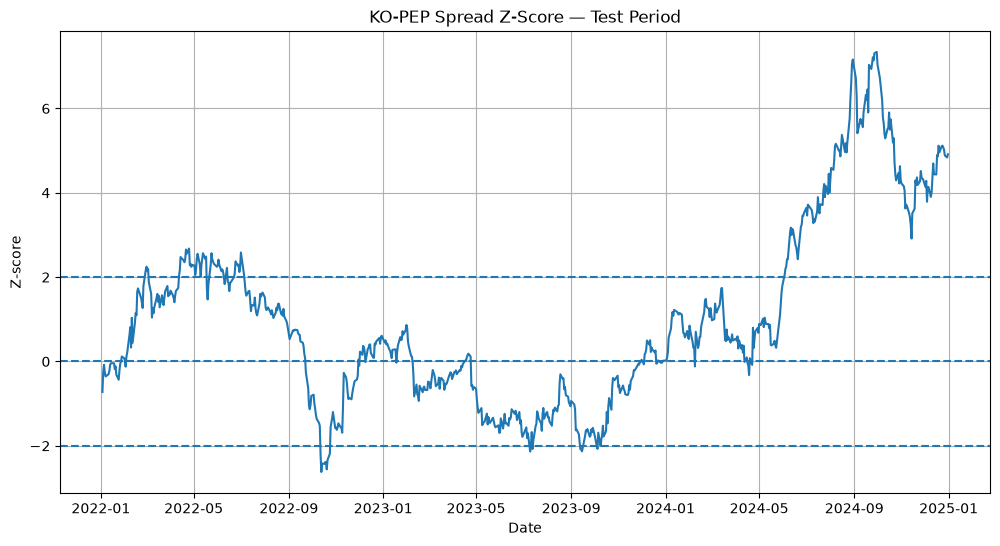

In [56]:
plt.figure(figsize=(12, 6))

plt.plot(zscore_test)

plt.axhline(0, linestyle="--")
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")

plt.title("KO-PEP Spread Z-Score — Test Period")
plt.xlabel("Date")
plt.ylabel("Z-score")

plt.grid(True)

plt.show()
#graph of z-scores during test period

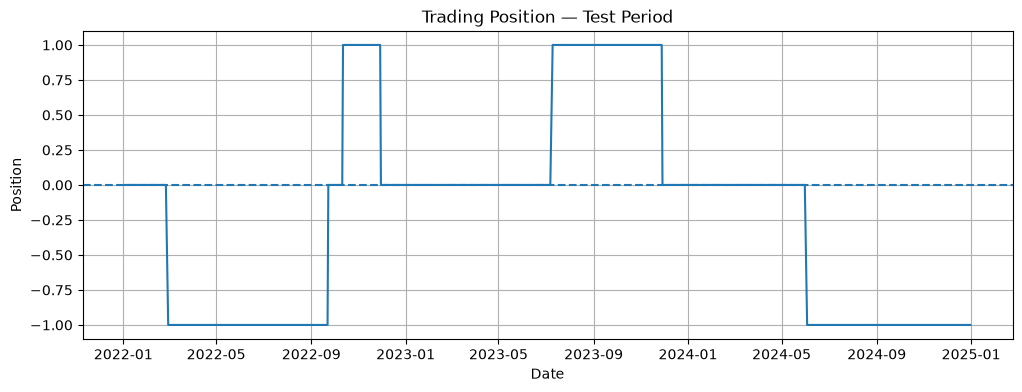

In [57]:
position_test=run_pairs_strategy(zscore_test,2,0)

plt.figure(figsize=(12, 4))

plt.plot(position_test)

plt.axhline(0, linestyle="--")

plt.title("Trading Position — Test Period")
plt.xlabel("Date")
plt.ylabel("Position")

plt.grid(True)

plt.show()
#graph of trading positions during test period

In [58]:
position_test.value_counts()

#counts of number of days with no trade, high trade, low trade

 0.0    328
-1.0    291
 1.0    134
Name: count, dtype: int64

In [59]:
entries_test = ((position_test != 0) & (position_test.shift(1) == 0)).sum()
print(f"Test entries: {entries_test}")

exits_test = ((position_test == 0) & (position_test.shift(1) != 0)).sum()
print(f"Test exits: {exits_test}")

#count number of entries and exits during testing

Test entries: 4
Test exits: 4


In [60]:
ko_change_test = test["KO"].diff()
pep_change_test = test["PEP"].diff()

spread_pnl_test = (
    ko_change_test
    - beta_train * pep_change_test
)
gross_notional_test = (
    test["KO"].shift(1)
    + beta_train * test["PEP"].shift(1)
)
spread_portfolio_return_test = (
    spread_pnl_test / gross_notional_test
)
strategy_returns_test = (
    position_test.shift(1)
    * spread_portfolio_return_test
).dropna()

#calculations similar to section above (comments are similar)

In [61]:
position_change_test = position_test.diff().abs()

costs_test = (
    transaction_cost * position_change_test
).fillna(0)
strategy_returns_test_net = (
    strategy_returns_test
    - costs_test.loc[strategy_returns_test.index]
)

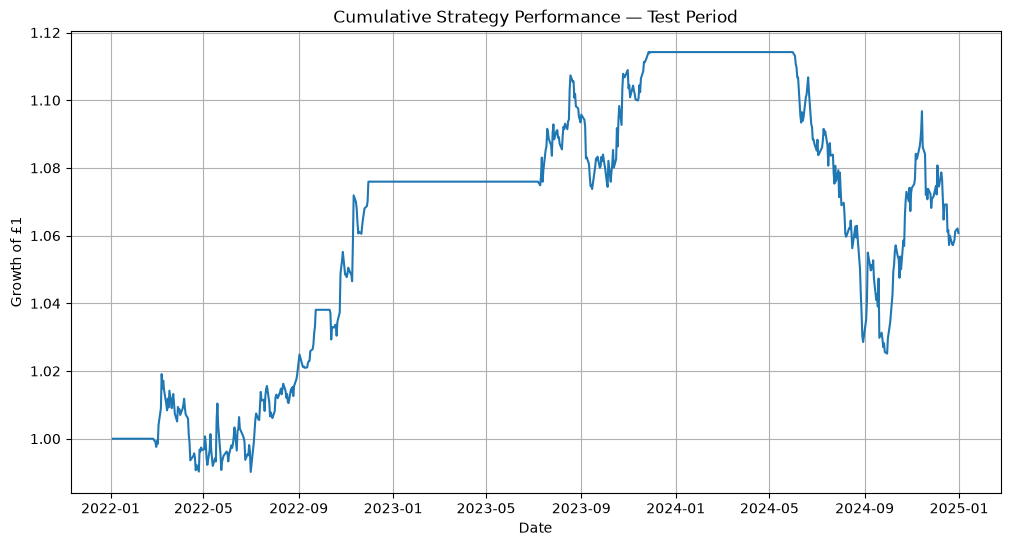

In [62]:
cumulative_test = (
    1 + strategy_returns_test_net
).cumprod()
plt.figure(figsize=(12, 6))

plt.plot(cumulative_test)

plt.title("Cumulative Strategy Performance — Test Period")
plt.xlabel("Date")
plt.ylabel("Growth of £1")

plt.grid(True)

plt.show()

In [63]:
test_total_return = cumulative_test.iloc[-1] - 1

print(f"Test total return: {test_total_return:.2%}")

Test total return: 6.08%


In [64]:
test_sharpe = (
    strategy_returns_test_net.mean()
    / strategy_returns_test_net.std()
) * np.sqrt(252)

print(f"Test Sharpe ratio: {test_sharpe:.4f}")

Test Sharpe ratio: 0.4581


In [65]:
running_max_test = cumulative_test.cummax()

drawdown_test = (
    cumulative_test - running_max_test
) / running_max_test

max_drawdown_test = drawdown_test.min()

print(f"Test maximum drawdown: {max_drawdown_test:.2%}")

Test maximum drawdown: -8.00%


In [66]:
print("TRAINING PERIOD")
print(f"Total return: {net_total_return:.2%}")
print(f"Sharpe ratio: {net_sharpe:.4f}")
print(f"Max drawdown: {max_drawdown:.2%}")

print("\nTEST PERIOD")
print(f"Total return: {test_total_return:.2%}")
print(f"Sharpe ratio: {test_sharpe:.4f}")
print(f"Max drawdown: {max_drawdown_test:.2%}")

#final results

TRAINING PERIOD
Total return: 20.74%
Sharpe ratio: 0.6029
Max drawdown: -7.36%

TEST PERIOD
Total return: 6.08%
Sharpe ratio: 0.4581
Max drawdown: -8.00%


## 4.2 Trade-Level Analysis

Aggregate performance is insufficient to fully evaluate a trading strategy.

We therefore examine individual trades to determine:

- when each trade was entered,
- when it was exited,
- whether it was long or short,
- and the return generated by each trade.

This helps identify whether strategy performance is consistent or driven by
a small number of trades.

In [67]:
trade_id = ((position_test != position_test.shift(1)) & (position_test != 0)).cumsum()

trade_id = trade_id.where(position_test != 0)

#assign an id for each trade

In [68]:
trade_returns = (
    strategy_returns_test_net
    .groupby(trade_id.loc[strategy_returns_test_net.index])
    .apply(lambda x: (1 + x).prod() - 1)
)
print(trade_returns)

#outputting the returns of each individual trade

1.0    0.033016
2.0    0.030873
3.0    0.035275
4.0   -0.047961
dtype: float64


In [69]:
trade_summary = pd.DataFrame({
    "Trade Return": trade_returns
})

trade_summary.index.name = "Trade"

trade_summary

#table of results above

,Trade Return
Trade,
1.0,0.033016
2.0,0.030873
3.0,0.035275
4.0,-0.047961


In [70]:
print(f"Average trade return: {trade_returns.mean():.2%}")
print(f"Winning trades: {(trade_returns > 0).sum()}")
print(f"Losing trades: {(trade_returns < 0).sum()}")

#calculations with results printed

Average trade return: 1.28%
Winning trades: 3
Losing trades: 1


In [71]:
win_rate = (trade_returns > 0).mean()

print(f"Win rate: {win_rate:.2%}")

#out of the four trades made in testing, 3 are winning, hence win rate is 3/4=75%

Win rate: 75.00%


In [72]:
winning_trades = trade_returns[trade_returns > 0]
losing_trades = trade_returns[trade_returns < 0]

print(f"Average winning trade: {winning_trades.mean():.2%}")
print(f"Average losing trade: {losing_trades.mean():.2%}")

#average win/lose rates for winning/losing trades

Average winning trade: 3.31%
Average losing trade: -4.80%


In [73]:
profit_factor = (
    winning_trades.sum()
    / abs(losing_trades.sum())
)

print(f"Profit factor: {profit_factor:.4f}")

#profit factor is total profit/ total loss

Profit factor: 2.0676


In [93]:
trade_dates = []

in_trade = False
entry_date = None
entry_position = None

for date in position_test.index:
    pos = position_test.loc[date]
    if not in_trade and pos != 0:
        entry_date = date
        entry_position = pos
        in_trade = True
    elif in_trade and pos == 0:
        trade_dates.append(
            (entry_date, date, entry_position)
        )
        in_trade = False

# If a trade is still open at the end of the test period
if in_trade:
    trade_dates.append(
        (entry_date, position_test.index[-1], entry_position)
    )

#for each trade, we note the entry and exit date, as long as its nature (short/long)

In [75]:
trade_table = pd.DataFrame(
    trade_dates,
    columns=["Entry Date", "Exit Date", "Position"]
)

trade_table["Position"] = trade_table["Position"].map({
    1: "Long Spread",
    -1: "Short Spread"
})

trade_table

#table of results above

,Entry Date,Exit Date,Position
0,2022-02-28,2022-09-23,Short Spread
1,2022-10-12,2022-11-30,Long Spread
2,2023-07-10,2023-11-29,Long Spread
3,2024-06-03,2024-12-31,Short Spread


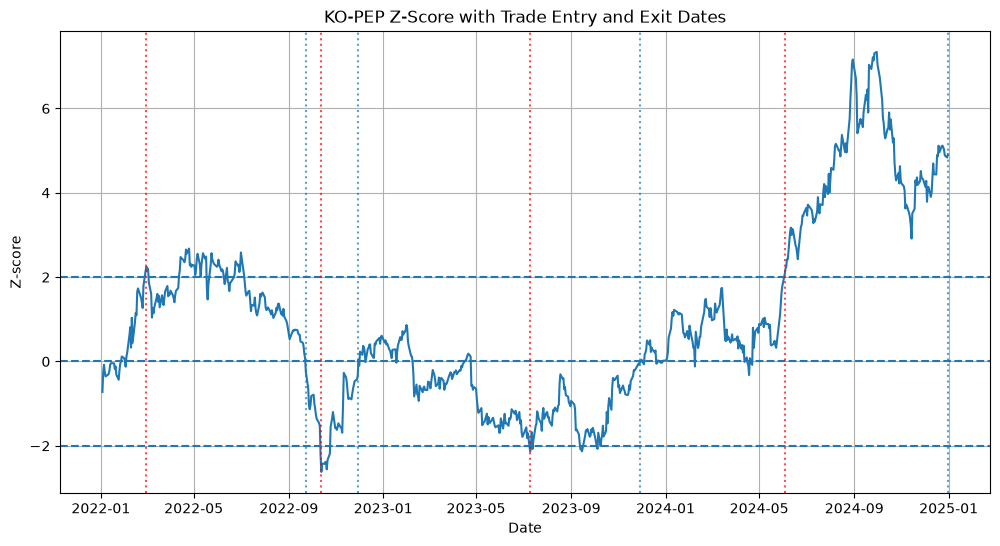

In [94]:
plt.figure(figsize=(12, 6))

plt.plot(zscore_test, label="Z-score")

plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.axhline(0, linestyle="--")

for entry, exit, pos in trade_dates:

    plt.axvline(entry, linestyle=":", alpha=0.7, color='red')
    plt.axvline(exit, linestyle=":", alpha=0.7)

plt.title("KO-PEP Z-Score with Trade Entry and Exit Dates")
plt.xlabel("Date")
plt.ylabel("Z-score")

plt.grid(True)
plt.show()

#z-score across the entire data set, now with entry and exit dates denoted; each trade starts with red and ends with blue

## 4.3 Preliminary Out-of-Sample Findings

The pairs-trading strategy remained profitable during the out-of-sample
period, generating a net return of 6.08%.

However, performance deteriorated relative to the training period. The
annualised Sharpe ratio fell from 0.603 during training to 0.458 during
testing, while maximum drawdown increased from 7.36% to 8.00%.

The test period produced four completed trades, of which three were
profitable and one was unprofitable. The winning trades averaged 3.31%,
while the losing trade returned -4.80%, resulting in a profit factor of
2.07.

The results suggest that the strategy captures some mean-reverting behaviour
in the KO-PEP relationship, but the relationship is not consistently stable.
In particular, the large divergence observed during 2024 demonstrates that
an extreme z-score does not necessarily imply imminent mean reversion.

The small number of trades also means that the results should not be
interpreted as statistically conclusive.

### 4.3.1 Analysis of the 2024 Divergence

The final test-period trade provides an important example of model risk.

The strategy entered a short-spread position when the z-score exceeded the
entry threshold of +2. However, instead of reverting toward zero, the
z-score continued to increase substantially.

We examine the maximum z-score reached during the trade to quantify the
extent of this divergence.

In [77]:
last_trade = trade_dates[-1]

last_entry = last_trade[0]
last_exit = last_trade[1]

last_trade_zscore = zscore_test.loc[
    last_entry:last_exit
]

print(f"Entry z-score: {last_trade_zscore.iloc[0]:.2f}")
print(f"Maximum z-score: {last_trade_zscore.max():.2f}")
print(f"Minimum z-score: {last_trade_zscore.min():.2f}")

holding_period = (
    last_exit - last_entry
).days

print(f"Final trade holding period: {holding_period} days")

#more statistics on the final trade shown

Entry z-score: 2.06
Maximum z-score: 7.34
Minimum z-score: 2.06
Final trade holding period: 211 days


In [78]:
trade_holding_periods = []

for entry, exit, position in trade_dates:
    days = (exit - entry).days
    trade_holding_periods.append(days)

trade_table["Holding Period (days)"] = trade_holding_periods

trade_table

#table of trades with duration of each trade appended

,Entry Date,Exit Date,Position,Holding Period (days)
0,2022-02-28,2022-09-23,Short Spread,207
1,2022-10-12,2022-11-30,Long Spread,49
2,2023-07-10,2023-11-29,Long Spread,142
3,2024-06-03,2024-12-31,Short Spread,211


In [79]:
print(
    f"Average holding period: "
    f"{trade_table['Holding Period (days)'].mean():.1f} days"
)

print(
    f"Maximum holding period: "
    f"{trade_table['Holding Period (days)'].max()} days"
)

Average holding period: 152.2 days
Maximum holding period: 211 days


### 4.3.2 Entry and Exit Threshold Sensitivities

The strategy was evaluated using entry thresholds of 1.5, 2.0, 2.5 and 3.0 standard deviations, while keeping the exit threshold fixed at zero,for entry threshold sensitivity. Entry threshold is fixed at 0 and different exit thresholds of 0, 0.25, 0.5, 0.75 and 1.0 for exit threshold sensitivity.

These results would provide some evidence that the strategy exhibits robustness across a range of reasonable entry parameters. However, the parameter selection remains based on the training period, and any chosen specification must be evaluated on unseen data before conclusions about its performance can be drawn.

In [80]:
entry_thresholds = [1.5, 2.0, 2.5, 3.0]
results = []

for threshold in entry_thresholds:
    position_temp = run_pairs_strategy(zscore_train,threshold,0)
    position_change_temp = position_temp.diff().abs()
    costs_temp = (transaction_cost * position_change_temp).fillna(0)
    strategy_temp = (position_temp.shift(1)*spread_portfolio_return).dropna()
    strategy_temp_net = (strategy_temp - costs_temp.loc[strategy_temp.index])

    cumulative_temp = (1 + strategy_temp_net).cumprod()
    total_return_temp = (cumulative_temp.iloc[-1] - 1)
    sharpe_temp = (strategy_temp_net.mean() / strategy_temp_net.std()) * np.sqrt(252)
    running_max_temp = cumulative_temp.cummax()
    drawdown_temp = (cumulative_temp - running_max_temp) / running_max_temp
    max_drawdown_temp = drawdown_temp.min()
    entries_temp = ((position_temp != 0) & (position_temp.shift(1) == 0)).sum()

    results.append({
        "Entry Threshold": threshold,
        "Total Return": total_return_temp,
        "Sharpe": sharpe_temp,
        "Max Drawdown": max_drawdown_temp,
        "Entries": entries_temp
    })

#varying the entry thresholds and computing the resulting statistics for each one

In [81]:
robustness_results = pd.DataFrame(results)

robustness_results

#table of results above

,Entry Threshold,Total Return,Sharpe,Max Drawdown,Entries
0,1.5,0.343811,0.844845,-0.073575,7
1,2.0,0.207356,0.602855,-0.073575,4
2,2.5,0.141308,0.638248,-0.063868,2
3,3.0,0.165249,0.746684,-0.063868,2


In [82]:
robustness_results.style.format({
    "Entry Threshold": "{:.1f}",
    "Total Return": "{:.2%}",
    "Sharpe": "{:.3f}",
    "Max Drawdown": "{:.2%}",
    "Entries": "{:.0f}"
})

#reformatting the data

,Entry Threshold,Total Return,Sharpe,Max Drawdown,Entries
0,1.5,34.38%,0.845,-7.36%,7
1,2.0,20.74%,0.603,-7.36%,4
2,2.5,14.13%,0.638,-6.39%,2
3,3.0,16.52%,0.747,-6.39%,2


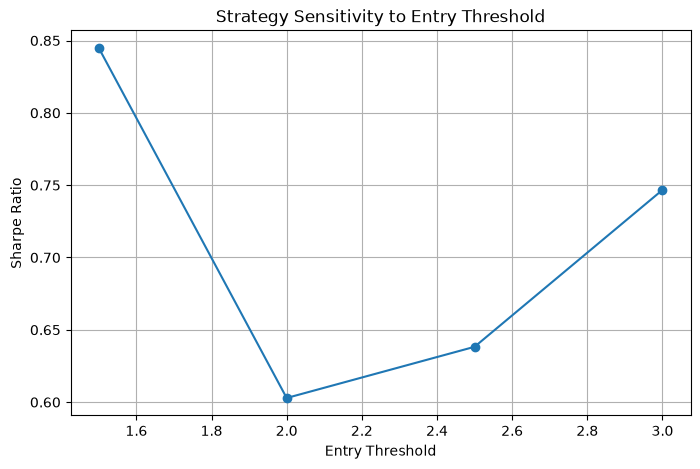

In [83]:
plt.figure(figsize=(8, 5))

plt.plot(
    robustness_results["Entry Threshold"],
    robustness_results["Sharpe"],
    marker="o"
)

plt.xlabel("Entry Threshold")
plt.ylabel("Sharpe Ratio")
plt.title("Strategy Sensitivity to Entry Threshold")

plt.grid(True)
plt.show()

#graph of sharpe ratio

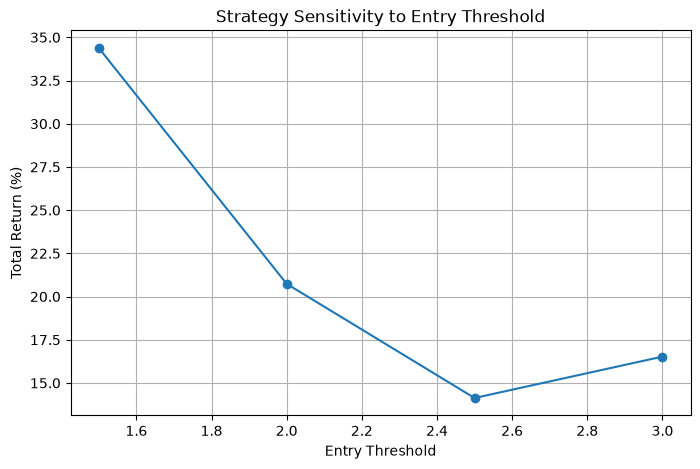

In [84]:
plt.figure(figsize=(8, 5))

plt.plot(
    robustness_results["Entry Threshold"],
    robustness_results["Total Return"] * 100,
    marker="o"
)

plt.xlabel("Entry Threshold")
plt.ylabel("Total Return (%)")
plt.title("Strategy Sensitivity to Entry Threshold")

plt.grid(True)
plt.show()

#graph of total return

In [85]:
exit_thresholds = [0, 0.25, 0.5, 0.75, 1.0]
exit_results = []

for exit_threshold in exit_thresholds:
    position_temp = run_pairs_strategy(zscore_train,2,exit_threshold)
    strategy_returns_temp = position_temp.shift(1) * spread_portfolio_return
    costs = transaction_cost * position_temp.diff().abs()
    net_returns_temp = strategy_returns_temp - costs
    total_return = (1 + net_returns_temp).prod() - 1

    sharpe = (net_returns_temp.mean() / net_returns_temp.std()) * np.sqrt(252)
    cumulative = (1 + net_returns_temp).cumprod()
    drawdown = cumulative / cumulative.cummax() - 1
    max_drawdown = drawdown.min()
    entries = ((position_temp.shift(1) == 0) & (position_temp != 0)).sum()

    exit_results.append({
        "Exit Threshold": exit_threshold,
        "Total Return": total_return,
        "Sharpe": sharpe,
        "Max Drawdown": max_drawdown,
        "Entries": entries
    })

exit_results_df = pd.DataFrame(exit_results)

exit_results_df

#similar to above but we vary the exit thresholds

,Exit Threshold,Total Return,Sharpe,Max Drawdown,Entries
0,0.00,0.207356,0.602855,-0.073575,4
1,0.25,0.219786,0.632313,-0.073575,4
2,0.50,0.236956,0.660577,-0.073575,4
3,0.75,0.165939,0.433746,-0.084712,3
4,1.00,0.200298,0.478297,-0.084712,3


In [86]:
position_test_final = run_pairs_strategy(zscore_test,2,0.5)
strategy_returns_test_final = position_test_final.shift(1) * spread_portfolio_return_test
costs_test_final = transaction_cost * position_test_final.diff().abs()
net_returns_test_final = strategy_returns_test_final - costs_test_final

total_return_test_final = (1 + net_returns_test_final).prod() - 1
sharpe_test_final = (net_returns_test_final.mean() / net_returns_test_final.std()) * np.sqrt(252)
cumulative_test_final = (1 + net_returns_test_final).cumprod()
drawdown_test_final = (cumulative_test_final / cumulative_test_final.cummax()) - 1
max_drawdown_test_final = drawdown_test_final.min()
entries_test_final = ((position_test_final.shift(1) == 0) & (position_test_final != 0)).sum()

print(f"Total Return: {total_return_test_final:.2%}")
print(f"Sharpe Ratio: {sharpe_test_final:.3f}")
print(f"Max Drawdown: {max_drawdown_test_final:.2%}")
print(f"Entries: {entries_test_final}")

#calculations

Total Return: 8.59%
Sharpe Ratio: 0.620
Max Drawdown: -8.08%
Entries: 4


In [87]:
print("TRAINING")
print(f"Total Return: 23.70%")
print(f"Sharpe Ratio: 0.661")
print(f"Max Drawdown: -7.36%")

print("\nTEST")
print(f"Total Return: {total_return_test_final:.2%}")
print(f"Sharpe Ratio: {sharpe_test_final:.3f}")
print(f"Max Drawdown: {max_drawdown_test_final:.2%}")

#final results

TRAINING
Total Return: 23.70%
Sharpe Ratio: 0.661
Max Drawdown: -7.36%

TEST
Total Return: 8.59%
Sharpe Ratio: 0.620
Max Drawdown: -8.08%


### 4.3.3 Final Out-of-Sample Performance

All tested thresholds produced positive returns and positive Sharpe ratios during the training period. Performance was therefore not exclusively dependent on the original choice of an entry threshold of ±2 standard deviations.

The threshold of 1.5 produced the highest training-period return and Sharpe ratio, while higher thresholds generated fewer trades and slightly lower maximum drawdowns.

After evaluating entry and exit threshold sensitivity using only the training period, the strategy was fixed with an entry threshold of ±2.0 standard deviations and an exit threshold of ±0.5 standard deviations.

The strategy was then evaluated on the previously untouched test period (2022–2024), without recalibrating the hedge ratio, spread mean, spread standard deviation, or trading parameters.

The training period produced a total return of 23.70%, a Sharpe ratio of 0.661 and a maximum drawdown of -7.36%.

On the out-of-sample test period, the strategy produced a total return of 8.59%, a Sharpe ratio of 0.620 and a maximum drawdown of -8.08%.

The relatively small reduction in Sharpe ratio from 0.661 to 0.620 suggests that the strategy's risk-adjusted performance was reasonably stable out of sample. The similar maximum drawdowns also provide some evidence against severe overfitting.

However, only four trades occurred during the test period. Therefore, the results should not be considered statistically conclusive. In particular, the small number of independent trading opportunities makes estimates of trade-level performance and Sharpe ratio relatively uncertain.

Overall, the results provide evidence that the KO/PEP pairs-trading strategy captured some degree of mean-reversion that persisted out of sample, although the limited number of trades and the changing relationship between the two securities remain important limitations.

### 4.3.4 Out-of-Sample Equity Curve and Drawdown

The out-of-sample equity curve shows that the strategy generated a positive
return over the 2022–2024 test period. The strategy achieved a total net
return of 8.59%, with an annualised Sharpe ratio of 0.620.

The maximum drawdown was -8.08%, indicating that the strategy experienced
moderate periods of adverse performance but did not suffer a severe
drawdown.

The z-score plot illustrates the relationship between the statistical
signals and the resulting trades. Positions were opened when the spread
moved beyond ±2 standard deviations and closed once the spread moved back
within ±0.5 standard deviations.

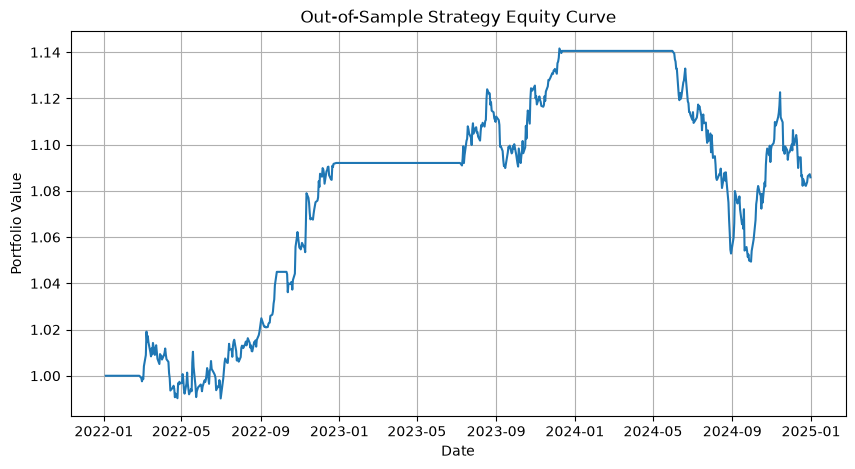

In [88]:
plt.figure(figsize=(10, 5))

plt.plot(
    cumulative_test_final.index,
    cumulative_test_final
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.title("Out-of-Sample Strategy Equity Curve")

plt.grid(True)
plt.show()

#graph of equity curve, which tracks the cumulative profit/loss during the test period

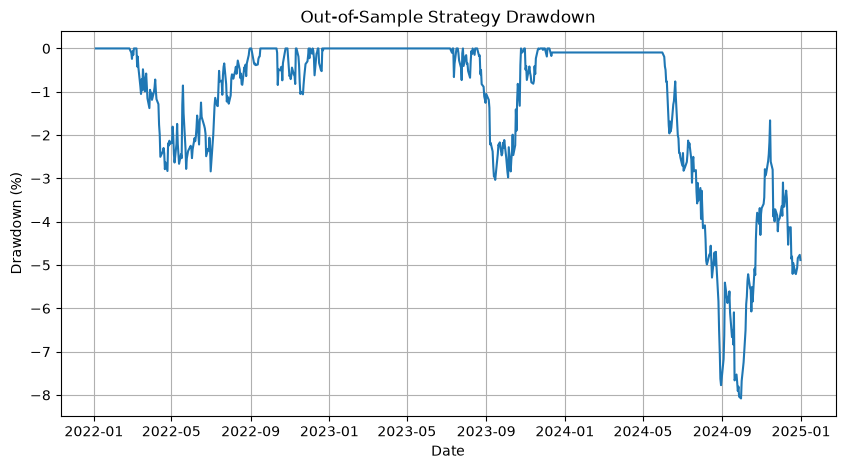

In [89]:
plt.figure(figsize=(10, 5))

plt.plot(
    drawdown_test_final.index,
    drawdown_test_final * 100
)

plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.title("Out-of-Sample Strategy Drawdown")

plt.grid(True)
plt.show()

#graph of drawdown percentages plotted

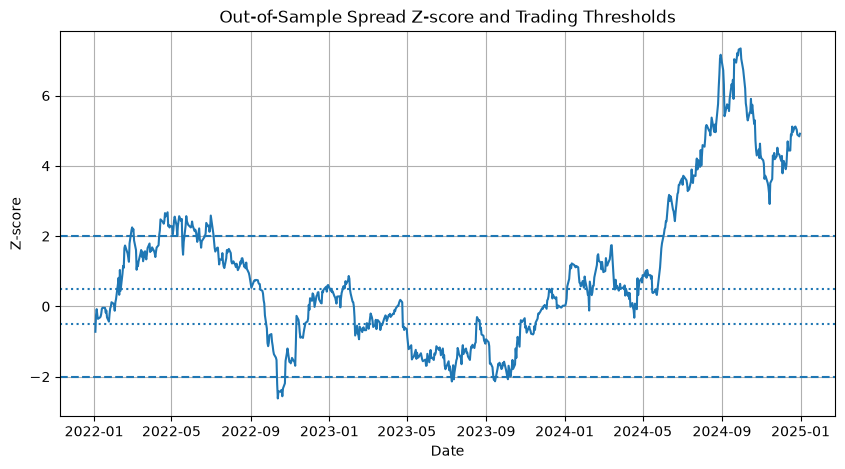

In [90]:
plt.figure(figsize=(10, 5))

plt.plot(
    zscore_test.index,
    zscore_test
)

plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.axhline(0.5, linestyle=":")
plt.axhline(-0.5, linestyle=":")

plt.xlabel("Date")
plt.ylabel("Z-score")
plt.title("Out-of-Sample Spread Z-score and Trading Thresholds")

plt.grid(True)
plt.show()

#graph of z-scores, now with optimised entry/exit thresholds denoted

### 4.3.5 Benchmark Comparison

The pairs-trading strategy was compared against simple buy-and-hold
benchmarks over the same 2022–2024 test period.

The pairs strategy generated a net return of 8.59%. This was lower than the
14.91% return from holding KO alone, but higher than the -4.18% return from
holding PEP alone and the 5.48% return from an equal-weight KO/PEP portfolio.

Therefore, the pairs strategy did not outperform every possible benchmark.
However, it generated a higher return than the simple equal-weight portfolio
while taking a fundamentally different approach based on relative pricing
and mean reversion rather than directional exposure to a single stock.

The comparison highlights an important limitation: positive absolute returns
do not necessarily demonstrate that statistical arbitrage is superior to
buy-and-hold. A more complete comparison would also examine volatility,
drawdown, market exposure and risk-adjusted performance.

In [91]:
ko_returns = test["KO"].pct_change()
pep_returns = test["PEP"].pct_change()

equal_weight_returns = 0.5 * ko_returns + 0.5 * pep_returns

ko_total_return = (1 + ko_returns.dropna()).prod() - 1
pep_total_return = (1 + pep_returns.dropna()).prod() - 1
equal_weight_total_return = (
    (1 + equal_weight_returns.dropna()).prod() - 1
)

print(f"KO Buy & Hold: {ko_total_return:.2%}")
print(f"PEP Buy & Hold: {pep_total_return:.2%}")
print(f"50/50 KO-PEP: {equal_weight_total_return:.2%}")
print(f"Pairs Strategy: {total_return_test_final:.2%}")

#returns for different strategies are calculated

KO Buy & Hold: 14.91%
PEP Buy & Hold: -4.18%
50/50 KO-PEP: 5.48%
Pairs Strategy: 8.59%


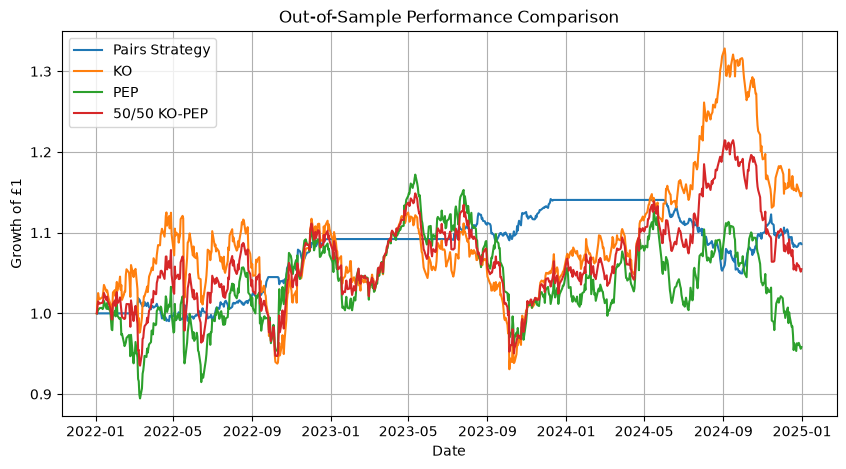

In [92]:
benchmark_df = pd.DataFrame({
    "Pairs Strategy": cumulative_test_final,
    "KO": (1 + ko_returns.fillna(0)).cumprod(),
    "PEP": (1 + pep_returns.fillna(0)).cumprod(),
    "50/50 KO-PEP": (1 + equal_weight_returns.fillna(0)).cumprod()
})

plt.figure(figsize=(10, 5))

plt.plot(benchmark_df.index, benchmark_df["Pairs Strategy"], label="Pairs Strategy")
plt.plot(benchmark_df.index, benchmark_df["KO"], label="KO")
plt.plot(benchmark_df.index, benchmark_df["PEP"], label="PEP")
plt.plot(benchmark_df.index, benchmark_df["50/50 KO-PEP"], label="50/50 KO-PEP")

plt.xlabel("Date")
plt.ylabel("Growth of £1")
plt.title("Out-of-Sample Performance Comparison")
plt.legend()
plt.grid(True)
plt.show()

#graph of results above plotted

## 5. Limitations

Despite the positive out-of-sample performance, several limitations should be considered.

First, the test period contains only four completed trades, so the results are based on a relatively small sample and should not be interpreted as strong statistical evidence of profitability.

Second, the hedge ratio and spread distribution were estimated using the training period only. This avoids look-ahead bias, but it also means that the relationship between KO and PEP is assumed to remain sufficiently stable during the test period.

Third, the strategy experienced a prolonged divergence in 2024. The final short-spread position remained open at the end of the test period rather than naturally returning to the mean. This illustrates an important risk of pairs trading: a spread can remain mispriced for a long time or the
underlying relationship can change.

Transaction costs were included in the backtest, but the model uses a simplified cost assumption and does not explicitly model bid-ask spreads, market impact, borrowing costs for short positions, or execution delays.

Finally, only one pair was investigated in depth. A more comprehensive statistical-arbitrage study would examine a larger universe of stocks and perform pair selection using only information available at each point in time.

## 6. Conclusion

This project implemented and evaluated a statistical-arbitrage pairs-trading strategy using Coca-Cola (KO) and PepsiCo (PEP).

The relationship was tested using the Engle-Granger cointegration approach. Using only the training period, the pair produced statistically significant evidence of cointegration at the 5% level. A hedge ratio was then estimated from the training data and used to construct a stationary spread.

Trading signals were generated using the spread z-score. The strategy was backtested using a strict train/test split, with transaction costs included and no recalibration using test-period information.

Using an entry threshold of ±2 standard deviations and an exit threshold of ±0.5 standard deviations, the strategy achieved a 23.70% training-period return and an 8.59% out-of-sample test-period return. The annualised Sharpe ratio was 0.661 in training and 0.620 in testing, while maximum drawdown was
approximately 7–8%.

The relatively small deterioration in Sharpe ratio between the training and test periods provides some evidence that the strategy was not simply overfitted to the training data. However, the small number of test trades means that the results are not sufficient to establish persistent
profitability.

The project therefore demonstrates the mechanics and practical challenges of statistical arbitrage rather than proving that KO/PEP pairs trading is a profitable strategy in general.